***NEURAL NETWORK***


---



Question 1: What is Deep Learning? Briefly describe how it evolved and how it differs from traditional machine learning.

Answer: Deep Learning is a subset of machine learning that uses multi-layered artificial neural networks to automatically learn and extract patterns from massive datasets.

How it Evolved

1. The Perceptron (1950s): Began as a single-layer linear classifier. It couldn't solve non-linear problems like the XOR gate, leading to a freeze in AI research.
2. Backpropagation (1980s): Multi-layer networks emerged, using backpropagation to learn from mistakes across hidden layers.
3. The Boom (2010s–Present): Exploded due to the availability of Big Data and high-power GPUs/TPUs, enabling modern architectures like Transformers and LLMs.

Key Differences from Traditional ML

- Feature Extraction: Traditional ML requires humans to manually extract features; Deep Learning automatically extracts features hierarchically from raw data.
- Data Scale: Traditional ML plateaus in performance; Deep Learning thrives and continuously improves on massive datasets.
- Hardware & Time: Traditional ML runs quickly on standard CPUs, while Deep Learning requires heavy GPU computing power and can take days or weeks to train.

Question 2: Explain the basic architecture and functioning of a Perceptron. What are its
limitations?

Answer: A Perceptron is the simplest form of an artificial neuron, consisting of four main components:
- Inputs(x1,x2,...xn) : The raw features or incoming data points.
- Weights(w1,w2,..wn): Coefficients that determine the relative importance or strength of each input.
- Bias (b): An extra adjustable parameter that allows the activation function to shift up or down, helping the model fit the data better.
- Activation Function: A step function (usually a threshold function) that maps the final calculated value to a binary output (0 or 1).

Functioning

- Weighted Summation: The perceptron multiplies each input by its corresponding weight, sums them all together, and adds the bias: z = summition(xiwi+b)
- Activation: The net input (Z) is passed through the activation function.
- Output: If Z is greater than or equal to a certain threshold (usually 0), the perceptron fires and outputs a 1; otherwise, it outputs a 0.

Limitations

- Linear Separability Only: A single perceptron can only classify data that is linearly separable.
- Fails at Non-Linear Problems: It completely fails to solve simple non-linear logical operations, such as the XOR gate, where the data points cannot be separated by a straight line.
- No Feature Combinations: It cannot learn complex, hierarchical representations of data on its own without being stacked into a multi-layer network.

Question 3: Describe the purpose of activation function in neural networks. Compare
Sigmoid, ReLU, and Tanh functions.

Answer: The primary purpose of an activation function is to introduce non-linearity into a neural network.Without activation functions, no matter how many hidden layers you stack together, the entire network would just behave like a single linear regression model (Y = mX + b). Non-linear activation functions allow the network to learn complex patterns, fit non-linear boundaries, and solve complicated problems (like image recognition or language processing).
1. Sigmoid Function:
- sigma(z) = 1/1+e^-z
- output ranges between 0 to 1
- Pros: Ideal for binary classification at the output layer,Smooth gradient.
- Cons: Vanishing Gradient Problem: Gradients become close to 0 for very high/low inputs, halting training, Not zero-centered.
2. Tanh Function:
- tanh(z) = (e^z + e^-z)/(e^z + e^-z)
- output ranges between 0 to infinity.
- Pros: Zero-centered (outputs can be negative), making optimization easier than Sigmoid.
- Cons: Still suffers from the Vanishing Gradient Problem when neurons saturate at -1 or 1.
3. ReLU Function:
- f(z) = max(0,z)
- output ranges between 0 to infinity.
- Pros: Extremely fast to compute, Avoids vanishing gradients for positive values, Standard choice for hidden layers.
- Cons: Dying ReLU Problem: If inputs are negative, the gradient becomes exactly 0, and the neuron permanently "dies."

Question 4: What is the difference between Loss function and Cost function in neural networks? Provide examples.

Answer: Loss Function measures the error of a single training example. It quantifies how far off the network's prediction is from the true target value for one specific data point. On the other hand, Cost Function measures the average error across the entire training dataset (or a mini-batch). It is typically calculated by summing up the individual losses for all training examples and taking their average.


Question 5: What is the role of optimizers in neural networks? Compare Gradient
Descent, Adam, and RMSprop.

Answer: Optimizers are algorithms or methods used to adjust the attributes of the neural network, such as weights and learning rate, to minimize the loss/cost function. During training, the loss function calculates how inaccurate the network's predictions are. The optimizer's job is to read the gradients (the direction and magnitude of the error) and update the weights in a way that guides the network toward the global minimum, effectively teaching the model to make better predictions.

Comparison of Optimizers
1. Gradient Descent:
- How it works: Takes uniform steps in the opposite direction of the gradient.
- Pros: Simple and computationally inexpensive.
- Cons: Uses a fixed learning rate; easily gets stuck in local minima or saddle points.
2. RMSprop
- How it works: Uses a moving average of squared gradients to scale the learning rate.
- Pros: Adaptive learning rate per parameter; excellent for non-stationary problems (like RNNs).
- Cons: Can still oscillate heavily if the initial learning rate is set poorly.
3. Adam
- How it works: Combines Momentum (smooth steps using past gradients) and RMSprop (adaptive scaling).
- Pros: Industry standard; fast convergence with minimal hyperparameter tuning.
- Cons: Slightly more compute and memory intensive per step.


In [1]:
#6.Write a Python program to implement a single-layer perceptron from
# scratch using NumPy to solve the logical AND gate

import numpy as np

class Perceptron:
    def __init__(self, input_size, lr=0.1, epochs=10):
        self.weights = np.zeros(input_size)
        self.bias = 0.0
        self.lr = lr
        self.epochs = epochs

    def activation_function(self, x):
        return 1 if x >= 0 else 0

    def predict(self, inputs):
        z = np.dot(inputs, self.weights) + self.bias
        return self.activation_function(z)

    def train(self, training_inputs, labels):
        for epoch in range(self.epochs):
            for inputs, label in zip(training_inputs, labels):
                prediction = self.predict(inputs)
                error = label - prediction
                self.weights += self.lr * error * inputs
                self.bias += self.lr * error

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y = np.array([0, 0, 0, 1])
perceptron = Perceptron(input_size=2, lr=0.1, epochs=10)
perceptron.train(X, y)

print("Trained Weights:", perceptron.weights)
print("Trained Bias:", perceptron.bias)
print("\nTesting the Perceptron on AND Gate:")

for inputs in X:
    output = perceptron.predict(inputs)
    print(f"Input: {inputs} -> Predicted Output: {output}")

Trained Weights: [0.2 0.1]
Trained Bias: -0.20000000000000004

Testing the Perceptron on AND Gate:
Input: [0 0] -> Predicted Output: 0
Input: [0 1] -> Predicted Output: 0
Input: [1 0] -> Predicted Output: 0
Input: [1 1] -> Predicted Output: 1


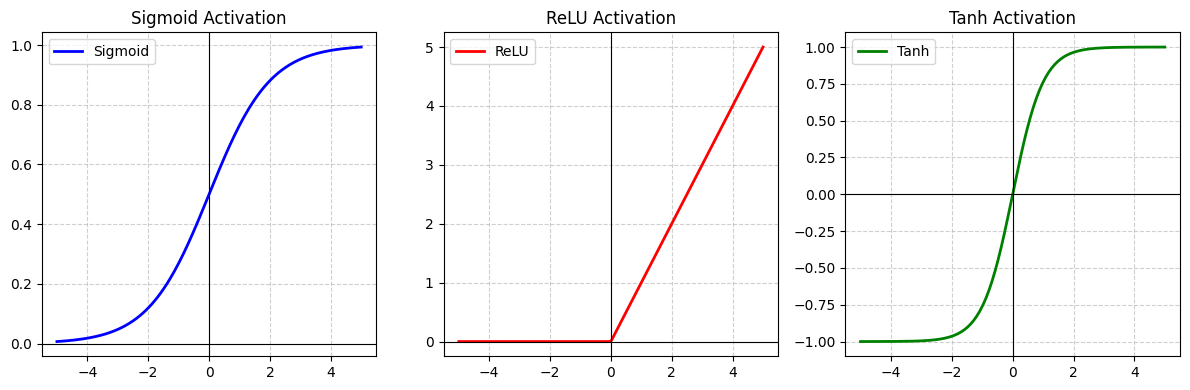

In [2]:
#  7: Implement and visualize Sigmoid, ReLU, and Tanh activation functions
# using Matplotlib.

import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def tanh(x):
    return np.tanh(x)

x = np.linspace(-5, 5, 200)
y_sigmoid = sigmoid(x)
y_relu = relu(x)
y_tanh = tanh(x)

plt.figure(figsize=(12, 4))
# Sigmoid
plt.subplot(1, 3, 1)
plt.plot(x, y_sigmoid, label="Sigmoid", color="blue", linewidth=2)
plt.title("Sigmoid Activation")
plt.grid(True, linestyle="--", alpha=0.6)
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)
plt.legend()
# ReLU
plt.subplot(1, 3, 2)
plt.plot(x, y_relu, label="ReLU", color="red", linewidth=2)
plt.title("ReLU Activation")
plt.grid(True, linestyle="--", alpha=0.6)
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)
plt.legend()
# Tanh
plt.subplot(1, 3, 3)
plt.plot(x, y_tanh, label="Tanh", color="green", linewidth=2)
plt.title("Tanh Activation")
plt.grid(True, linestyle="--", alpha=0.6)
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)
plt.legend()
plt.tight_layout()
plt.show()

In [3]:
# 8: Use Keras to build and train a simple multilayer neural network on the
# MNIST digits dataset. Print the training accuracy.

import tensorflow as tf
from tensorflow.keras import layers, models

mnist = tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training the network...")
history = model.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.1)
final_train_acc = history.history['accuracy'][-1]
print("\n" + "="*40)
print(f"Final Training Accuracy: {final_train_acc * 100:.2f}%")
print("="*40)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training the network...
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8955 - loss: 0.3633 - val_accuracy: 0.9625 - val_loss: 0.1484
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9487 - loss: 0.1767 - val_accuracy: 0.9723 - val_loss: 0.1058
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9606 - loss: 0.1327 - val_accuracy: 0.9747 - val_loss: 0.0940
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9685 - loss: 0.1065 - val_accuracy: 0.9780 - val_loss: 0.0824
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9720 - loss: 0.0907 - val_accuracy: 0.9782 - val_loss: 0.0769

Final Training Accuracy: 97.20%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training the model on Fashion MNIST...
Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7958 - loss: 0.5839 - val_accuracy: 0.8529 - val_loss: 0.4255
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8505 - loss: 0.4246 - val_accuracy: 0.8618 - val_loss: 0.3871
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8600 - loss: 0.3837 - val_accuracy: 0.8676 - val_loss: 0.3690
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8690 - loss: 0.3610 - val_accuracy: 0.8721 - val_loss: 0.3548
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8757 - loss: 0.3396 - val_accuracy: 0.8708 - val_loss: 0.3503
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8808 - loss: 0.3254 - val_accuracy: 0.8816 - val_loss: 0.3305
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8829 - loss: 0.3178 - val_accuracy: 0.8822 - val_loss: 0.3247
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0

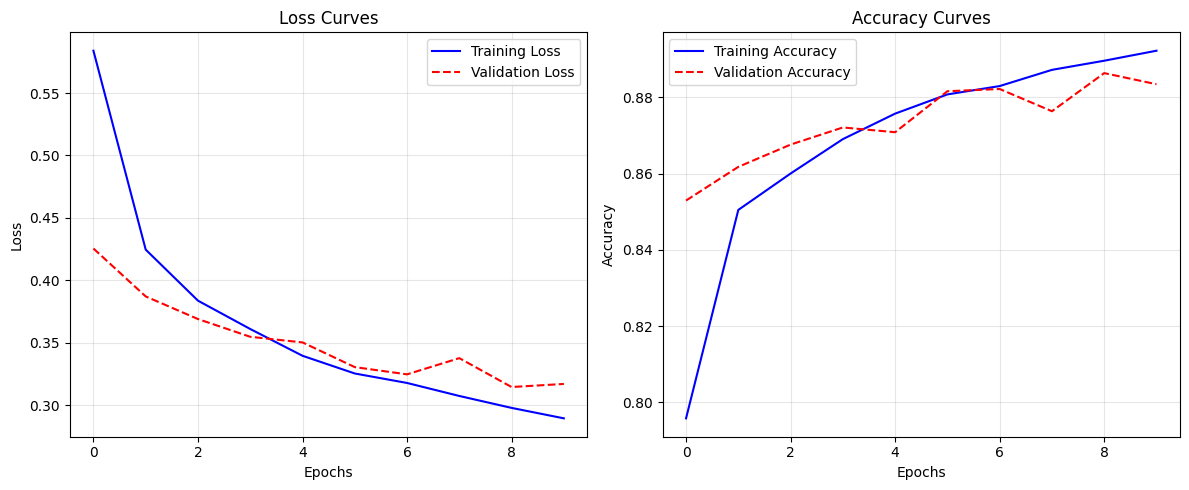

In [5]:
# 9: Visualize the loss and accuracy curves for a neural network model trained
# on the Fashion MNIST dataset. Interpret the training behavior.

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

fashion_mnist = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training the model on Fashion MNIST...")
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', color='blue', linestyle='-')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red', linestyle='--')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linestyle='--')
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

10: You are working on a project for a bank that wants to automatically detect
fraudulent transactions. The dataset is large, imbalanced, and contains structured
features like transaction amount, merchant ID, and customer location. The goal is to
classify each transaction as fraudulent or legitimate.
Explain your real-time data science workflow:
-  How would you design a deep learning model (perceptron or multilayer NN)?
-  Which activation function and loss function would you use, and why?
-  How would you train and evaluate the model, considering class imbalance?
- Which optimizer would be suitable, and how would you prevent overfitting?

Answer:
- I will design Multilayer Neural Network so that complex patterns can be easily catched during network training as fraud detection required comples learning or non - linear learning network.
- For activation function i will use ReLU in hidden layers which will avoid vanishing gradient problem and Sigmoid Function for output activation to get probability of fraud vs. legitimate and loss function will be Binary Cross Enrtropy as result would be 0 or 1 fraud vs legitimate.
- By Assigning weights with higher penality during fit model and resampling SMOTE technique to fix the imbalanced dataset. For evaluation metrices i will check mse,precession,f1-score and recall.
- Suitable optimizer would be Adam as it will learn from previous learning rate and handle massive dataset easily. To prevent over fitting i will use early stopping if validation performance stops improving for few echos stop training immediately to prevent model from overfitting.